# Simple Linear Regression
## Predicting AQI from Month

**What is Simple Linear Regression?**
- We have ONE input: Month (X)
- We have ONE output: AQI (y)
- We find a line: **y = mx + b**

**Simple Steps:**
1. Load data
2. Prepare X and y
3. Split train/test
4. Train model
5. Make predictions
6. Check accuracy

## Load and Check Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("done..")

done..


In [2]:

df = pd.read_csv('../Data/processed/clean_data.csv')

print(f"Total records: {len(df)}")
print(f"\nFirst 3 rows:")
print(df[['month', 'aqi_value']].head(3))

Total records: 425138

First 3 rows:
   month  aqi_value
0      6         49
1      6         46
2      6         26


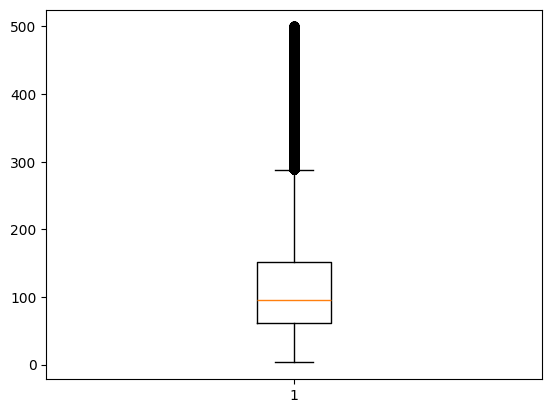

Clean records: 425138
Removed: 0


In [3]:

df_clean = df[['month', 'aqi_value']].dropna()
plt.boxplot(df_clean['aqi_value'])
plt.show()
print(f"Clean records: {len(df_clean)}")
print(f"Removed: {len(df) - len(df_clean)}")

Skewness: 1.4276
Method used: IQR
Rows before: 425138
Rows after : 403753
Outliers removed: 21385


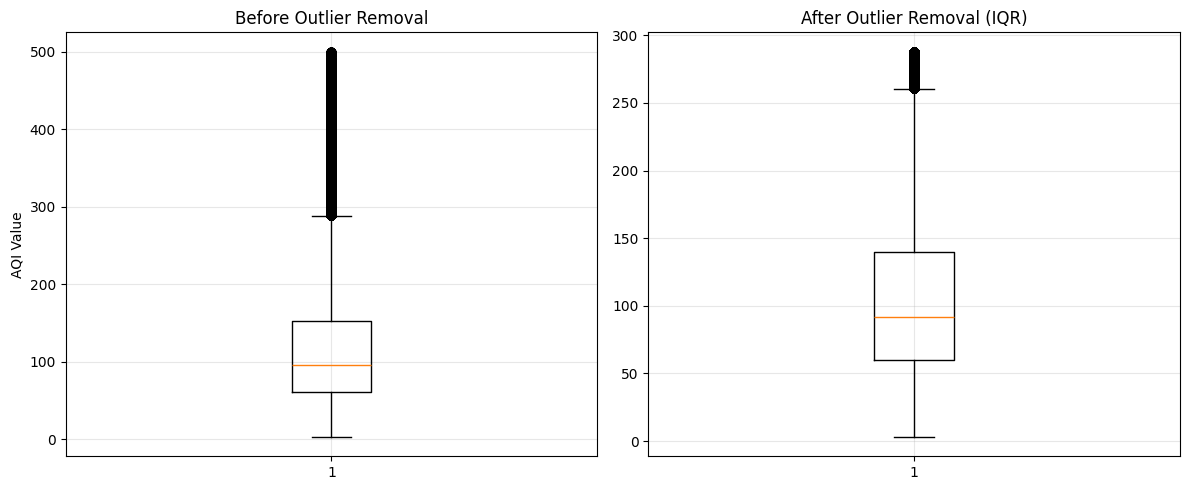

In [4]:
# Step 1.5: Simple outlier handling (aqi_value)
# Rule: skewed data -> IQR, otherwise -> Z-score

target = 'aqi_value'
skew_val = df_clean[target].skew()

df_before = df_clean.copy()

if abs(skew_val) > 0.5:
    q1 = df_clean[target].quantile(0.25)
    q3 = df_clean[target].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean = df_clean[(df_clean[target] >= lower) & (df_clean[target] <= upper)].copy()
    mth = 'IQR'
else:
    z_scores = np.abs(stats.zscore(df_clean[target], nan_policy='omit'))
    df_clean = df_clean[z_scores < 3].copy()
    mth = 'Z-score'

print(f"Skewness: {skew_val:.4f}")
print(f"Method used: {mth}")
print(f"Rows before: {len(df_before)}")
print(f"Rows after : {len(df_clean)}")
print(f"Outliers removed: {len(df_before) - len(df_clean)}")

 # before outlier removal  and after outlier removal chart
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].boxplot(df_before[target], vert=True)
ax[0].set_title('Before Outlier Removal')
ax[0].set_ylabel('AQI Value')
ax[0].grid(alpha=0.3)

ax[1].boxplot(df_clean[target], vert=True)
ax[1].set_title(f"After Outlier Removal ({mth})")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 2: Prepare Data

In [7]:
X = df_clean['month'].values.reshape(-1,1)
y = df_clean['aqi_value'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {len(X_train)}")
print(f"Testing data: {len(X_test)}")

Training data: 323002
Testing data: 80751


## Step 3: Train Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print("Model trained!")

print(f"\nFormula: AQI = {intercept:.2f} + {slope:.4f} x Month")
print(f"\nSlope: {slope:.4f}")
print(f"Intercept: {intercept:.2f}")

Model trained!

Formula: AQI = 113.56 + -1.0629 x Month

Slope: -1.0629
Intercept: 113.56


## Step 4: Make Predictions

In [59]:

y_pred = model.predict(X_test)
print("Sample Predictions:\n")
for i in range(5):
    print(f"Month {X_test[i][0]:.0f}: Actual={y_test[i]:.1f}, Predicted={y_pred[i]:.1f}")

Sample Predictions:

Month 7: Actual=113.0, Predicted=100.0
Month 2: Actual=160.0, Predicted=106.5
Month 11: Actual=185.0, Predicted=94.8
Month 8: Actual=103.0, Predicted=98.7
Month 2: Actual=63.0, Predicted=106.5


## Step 5: Evaluate Model

In [43]:
# Calculate accuracy metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:\n")
print(f"R² Score: {r2:.4f}")
print(f"  → Explains {r2*100:.1f}% of AQI")
print(f"\nMSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"  → Average error: ±{rmse:.2f} AQI")

Model Performance:

R² Score: 0.0064
  → Explains 0.6% of AQI

MSE: 3105.96
RMSE: 55.73
  → Average error: ±55.73 AQI


## Step 6: Visualize Results

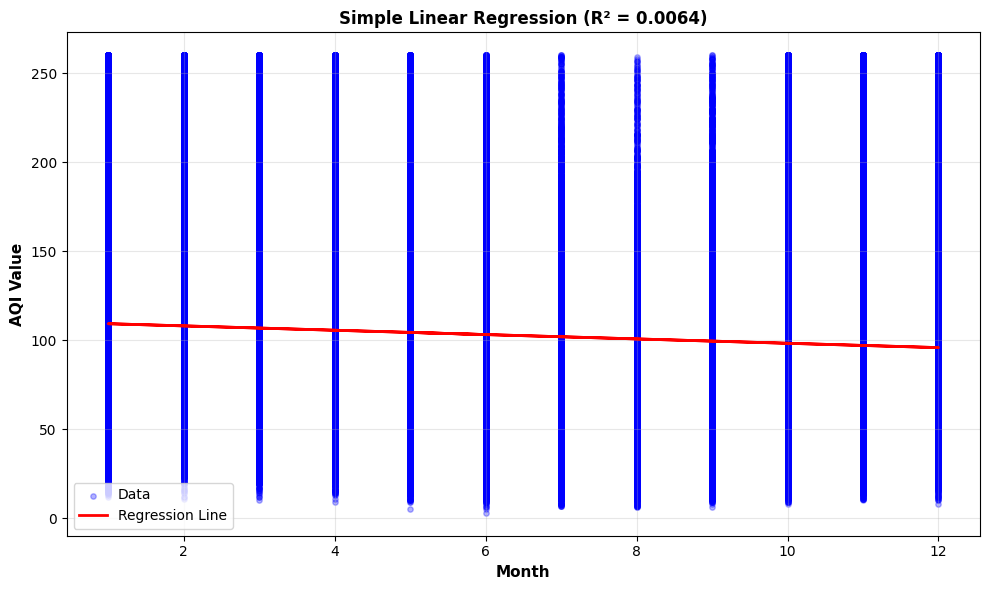

✓ Plot displayed


In [44]:
# Plot regression line
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.3, s=15, color='blue', label='Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Month', fontsize=11, fontweight='bold')
plt.ylabel('AQI Value', fontsize=11, fontweight='bold')
plt.title(f'Simple Linear Regression (R² = {r2:.4f})', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Plot displayed")

## Step 7: Summary

In [45]:

print("<< --- SIMPLE LINEAR REGRESSION SUMMARY  -->>")

print(f"\n Model trained with {len(X_train)} records")
print(f"\nFormula: AQI = {intercept:.2f} + {slope:.4f} × Month")
print(f"\nAccuracy (R²): {r2:.4f}")
print(f"\nError (RMSE): {rmse:.2f} AQI points")
print(f"\nTested on {len(X_test)} records")


<< --- SIMPLE LINEAR REGRESSION SUMMARY  -->>

 Model trained with 315235 records

Formula: AQI = 110.43 + -1.2203 × Month

Accuracy (R²): 0.0064

Error (RMSE): 55.73 AQI points

Tested on 78809 records
